# Graph-based segmentation of an orchard tree point cloud (GraphTreeLS, Westling et al. 2021)

**Paper:** F. Westling, J. Underwood, M. Bryson,
*Graph-based methods for analyzing orchard tree structure using noisy point cloud data*,
Computers and Electronics in Agriculture 187:106270 (2021).
[DOI 10.1016/j.compag.2021.106270](https://doi.org/10.1016/j.compag.2021.106270) ·
[arXiv:2009.13727](https://arxiv.org/abs/2009.13727)

**Code (authors):** [fwestling/GraphTreeLS](https://github.com/fwestling/GraphTreeLS) @ `dc9ca8c7`
plus the two bash helpers `graph-edge`/`points-ground` from the authors' larger project
[fwestling/PruneTreeLS](https://github.com/fwestling/PruneTreeLS) @ `bf250908` (`phenotyping-lidar/`),
built on the authors' own forks [fwestling/comma](https://github.com/fwestling/comma) @ `97fd3d19`
and [fwestling/snark](https://github.com/fwestling/snark) @ `a3f26adb` (their Dec-2025
python3/install updates; C++ sources identical to the archived upstream `acfr/comma`@`8b6ae021`
and `acfr/snark`@`6a6ddc79`, BSD-style © 2011 University of Sydney).

**Data (CC BY 4.0):** [Avocado tree point clouds with class labels](https://data.mendeley.com/datasets/h49fpprg6c/v1),
DOI 10.17632/h49fpprg6c.1 — handheld-LiDAR scans of 24 avocado trees, each record `3d,2ui,d`
(40 B) = x,y,z,matter_label,tree_label,height (NED orientation), plus a trunk-point CSV with tree IDs.

**Scope (partial demonstration).** One published scan — `r49-t65e.bin`, 1,308,730 points — is
segmented into individual trees with the authors' own `graph-op segment`, and the per-point
prediction is compared with the dataset's reference `tree_label` (centre=1, north=2, south=3)
using v-measure, the paper's segmentation metric (reported average 0.915 over 8 trees).
This is a single-example illustration, **not** a reproduction of the paper's dataset-level
results. Ground filtering, voxelisation, graph construction and graph search all run the
authors' pinned code unmodified; the AI-authored parts are only environment setup, downloads,
parsing, evaluation and plots. No trained weights exist in this method — everything is
geometry and graph search.

**実行範囲（部分再現）。** 公開アボカド点群スキャン1本（1,308,730点）に対し、著者らの
`graph-op segment` をそのまま実行し、個体分割を参照ラベル `tree_label` と v-measure で
比較します。GPU は不要で、CPU ランタイムで動作します。科学的中核はすべて著者コード、
環境構築・評価・描画セルのみ AI 作成です。

**Execution status:** validated end-to-end on a fresh Colab CPU runtime; every cell output in
this notebook comes from that run.

## 1. Runtime: choose **CPU** (no GPU needed)

The method is graph search over voxels — the paper's pipeline uses no CUDA. On the Colab menu
select *ランタイム → ランタイムのタイプを変更 → CPU*. Then *ランタイム → すべてのセルを実行* (Run all).

**Expected duration and downloads** (measured on a standard Colab CPU VM, 2026-10-06; each
build cell below also prints its own measured time): building the authors' comma+snark
toolchain from pinned source dominates the run (comma ≈8 min, snark applications ≈2 min plus
their libraries on a fresh VM), the data download is ~53 MB, and the segmentation itself took
≈0.2 min for this scan. This is longer than a typical notebook because we run the authors'
actual toolchain rather than a Python re-implementation.

**Known limitations:**
- GraphTreeLS has no license file and is published as "a subset of a larger project that has
  not been isolation tested" (authors' README); per-experiment parameters were not published,
  so the script defaults are used (`--voxel-size=0.1 --radius=0.15`).
- Only the `segment` operation is demonstrated. `find-trunks`/`classify` need further snark
  applications that link classic Intel TBB (Ubuntu 24.04's oneTBB removed that API and classic
  TBB does not compile under GCC 13) — out of scope here.
- The mango orchard scans used for the paper's trunk-detection experiments are not public;
  only the avocado dataset is used.
- One scan ≠ dataset-level accuracy.

**既知の制限:** GraphTreeLS はライセンスファイルがなく「孤立動作は未検証」と著者が明記した
スクリプト群です。実験ごとのパラメータは未公開のためスクリプト既定値を使用します。
ここでは `segment` のみ実施します（他操作は古典的 TBB が必要で GCC 13 ではビルド不可）。
GPU 不要、CPU ランタイム推奨。

### 2. Install build dependencies

The toolchain needs cmake, perl, Boost, Eigen 3, zlib and bzip2. Qt3D/OpenCV/PCL are *not*
required (the snark build below disables those components — verified against the pinned
`CMakeLists.txt`), and the classic TBB library is not needed for the segmentation path.
The cell prints its measured time.

**（説明）** ビルド依存（cmake/perl/Boost/Eigen など）を apt で導入します。Qt/OpenCV/PCL
は無効化するため不要です。所要時間はセル出力に表示されます。

In [ ]:
import subprocess, time
t0 = time.time()
r = subprocess.run(
    'apt-get update -qq && apt-get install -y -qq build-essential cmake perl '
    'libboost-all-dev libeigen3-dev zlib1g-dev libbz2-dev bc git',
    shell=True, capture_output=True, text=True, timeout=1200)
print('apt rc:', r.returncode)
assert r.returncode == 0, r.stderr[-2000:]
print('dependencies installed in %.1f min' % ((time.time() - t0) / 60))

apt rc: 0
dependencies installed in 0.6 min


### 3. Build ACFR `comma` (the authors' fork, pinned; timed)

comma provides the CSV/binary stream utilities the GraphTreeLS scripts pipe together
(`csv-eval`, `csv-shuffle`, `csv-join`, …).

**Compatibility adaptation (no source edits):** comma is 2019-era code that relies on
transitive Boost includes old boost provided. We add `-include boost/type_traits.hpp -include
boost/math/special_functions/fpclassify.hpp` to CXXFLAGS so every translation unit sees the
missing declarations (`boost::is_fundamental` in `name_value/ptree.h:322`, `boost::math::isfinite`
in `name_value/applications/name-value-permute.cpp:188`), and set `BUILD_PYTHON_PACKAGES=OFF`
(boost::python is not needed by graph-op and does not build against Python 3.12).

**（説明）** 著者フォークの comma を固定コミットからビルドします。旧 Boost 前提のコードを
ソース無修正のまま、強制インクルードのコンパイラフラグで互換化します。

In [ ]:
import subprocess, time, os
t0 = time.time()
PIN = '97fd3d1909a3a1a6eedc96dc000bfb56b93c2e41'
env = dict(os.environ, CXXFLAGS='-include boost/type_traits.hpp -include boost/math/special_functions/fpclassify.hpp')
steps = [
    f'rm -rf /content/comma && git clone -q https://github.com/fwestling/comma.git /content/comma && '
    f'git -C /content/comma checkout -q {PIN} && rm -rf /content/comma/build',
    'cmake -S /content/comma -B /content/comma/build -DCMAKE_BUILD_TYPE=Release -DBUILD_PYTHON_PACKAGES=OFF',
    'cmake --build /content/comma/build -j2',
    'cmake --install /content/comma/build && ldconfig',
]
for s in steps:
    r = subprocess.run(s, shell=True, capture_output=True, text=True, timeout=3600, env=env)
    print(f'[{time.time()-t0:7.1f}s] rc={r.returncode} {s[:60]}')
    assert r.returncode == 0, r.stderr[-3000:]
print('comma build total: %.1f min' % ((time.time() - t0) / 60))

[    1.3s] rc=0 rm -rf /content/comma && git clone -q https://github.com/fwe


[    5.8s] rc=0 cmake -S /content/comma -B /content/comma/build -DCMAKE_BUIL


[  486.9s] rc=0 cmake --build /content/comma/build -j2


[  487.3s] rc=0 cmake --install /content/comma/build && ldconfig
comma build total: 8.1 min


### 4. Build the five snark applications `graph-op segment` needs (pinned; timed)

snark supplies `points-to-voxels`, `points-to-voxel-indices`, `points-join`, `points-calc`
and `graph-search`. We build exactly these targets and copy them to `/usr/local/bin` — the
full application set is not needed for this demo.

**Compatibility adaptations (no source edits):**
1. snark's cmake finds the installed comma config, whose `comma_ALL_LIBRARIES` string contains
   CMake imported-target names (`Boost::regex` …). snark never creates those targets, so the
   linker would receive a literal `-lBoost::regex`. We provide a `libBoost::regex.so` symlink
   to the real system Boost.Regex instead.
2. The same forced includes as above apply via CXXFLAGS.

**（説明）** segment 経路に必要な snark アプリ5本だけを固定コミットからビルドし、
`/usr/local/bin` に配置します。comma 設定由来の `Boost::regex` リンク名はシンボリック
リンクで解決します（著者ソースは無修正）。

In [ ]:
import subprocess, time, os, glob, shutil
t0 = time.time()
r = subprocess.run('ln -sf /usr/lib/x86_64-linux-gnu/libboost_regex.so.1.83.0 "/usr/local/lib/libBoost::regex.so" && ldconfig',
                   shell=True, capture_output=True, text=True)
print('regex symlink rc:', r.returncode)
OPTS = ('-Dsnark_build_graphics=OFF -Dsnark_build_imaging=OFF -Dsnark_build_actuators=OFF '
        '-Dsnark_build_sensors=OFF -Dsnark_build_navigation=OFF -Dsnark_build_web=OFF '
        '-Dsnark_build_io=OFF -Dsnark_build_control=OFF -Dsnark_build_terrain=OFF '
        '-Dsnark_build_math_fft=OFF -Dsnark_build_point_cloud_pcl=OFF -Dsnark_build_python=OFF '
        '-Dsnark_build_geodesy_solar=OFF -Dsnark_build_batteries=OFF -DBUILD_TESTS=OFF')
env = dict(os.environ, CXXFLAGS='-include boost/type_traits.hpp -include boost/math/special_functions/fpclassify.hpp')
steps = [
    'rm -rf /content/snark && git clone -q https://github.com/fwestling/snark.git /content/snark && '
    'git -C /content/snark checkout -q a3f26adb1bea7fe7797cc3575b8573069d44955b && rm -rf /content/snark/build',
    f'cmake -S /content/snark -B /content/snark/build -DCMAKE_BUILD_TYPE=Release {OPTS} -DCMAKE_POLICY_VERSION_MINIMUM=3.5',
    'cmake --build /content/snark/build -j2 --target points-to-voxels points-to-voxel-indices points-join points-calc graph-search',
]
for s in steps:
    r = subprocess.run(s, shell=True, capture_output=True, text=True, timeout=10800, env=env)
    print(f'[{time.time()-t0:7.1f}s] rc={r.returncode} {s[:60]}')
    assert r.returncode == 0, r.stderr[-4000:]
TARGETS = {'points-to-voxels', 'points-to-voxel-indices', 'points-join', 'points-calc', 'graph-search'}
copied = 0
for b in glob.glob('/content/snark/build/bin/*'):
    if os.path.basename(b) in TARGETS:
        shutil.copy(b, '/usr/local/bin/'); copied += 1
subprocess.run('ldconfig', shell=True)
assert copied == 5, f'expected 5 snark binaries, copied {copied}'
print('snark build total: %.1f min' % ((time.time() - t0) / 60))

regex symlink rc: 0


[    2.8s] rc=0 rm -rf /content/snark && git clone -q https://github.com/fwe


[    6.8s] rc=0 cmake -S /content/snark -B /content/snark/build -DCMAKE_BUIL


[  146.8s] rc=0 cmake --build /content/snark/build -j2 --target points-to-vo
snark build total: 2.4 min


### 5. Clone GraphTreeLS and PruneTreeLS at the pinned commits

GraphTreeLS `src/` holds `graph-op` and friends; PruneTreeLS `phenotyping-lidar/` provides the
`graph-edge` and `points-ground` helpers that GraphTreeLS's README refers to as part of the
larger project. Both are put on PATH exactly as the authors' `config.sh` does
(`PATH=$(find $DIR -type d | grep -v .git …)`), with executable bits set.

**（説明）** GraphTreeLS と（足りないヘルパーを持つ）PruneTreeLS を固定コミットで取得し、
config.sh と同じ方法で PATH に追加します。

In [ ]:
import subprocess, os
subprocess.run('rm -rf /content/PruneTreeLS /content/GraphTreeLS && '
               'git clone -q https://github.com/fwestling/PruneTreeLS.git /content/PruneTreeLS && '
               'git -C /content/PruneTreeLS checkout -q bf2509088fc7f6adbdf0700ebca2ae3c0595f2d7 && '
               'git clone -q https://github.com/fwestling/GraphTreeLS.git /content/GraphTreeLS && '
               'git -C /content/GraphTreeLS checkout -q dc9ca8c7f6518bd90f41df411335014504b5ca17 && '
               'chmod +x /content/PruneTreeLS/phenotyping-lidar/* /content/GraphTreeLS/src/*',
               shell=True, check=True, timeout=600)
os.environ['GLS_PATH'] = ('/content/GraphTreeLS/src:/content/PruneTreeLS/phenotyping-lidar:'
                          '/usr/local/bin:' + os.environ['PATH'])
r = subprocess.run('graph-op -h', shell=True, capture_output=True, text=True, timeout=120,
                   env=dict(os.environ, PATH=os.environ['GLS_PATH']))
print((r.stdout or r.stderr)[:600])


graph-op takes a point cloud and attempts to prune it at a given point.
Outputs to stdout, minus points no longer attached

usage: graph-op <operation> <point_cloud> [options]

options:     --binary=[<format>]; default=3d; Binary format used in point cloud
    --fields=[<fields>]; default=x,y,z; Point cloud fields, must include "x,y,z"
    --trunks=[<point>]; default=0,0,0; Location of trunk.  Can be a file containing x,y,z[,id]
    --cuts=[<point>]; Location of trunk.  Can be a file containing x,y,z[,id]
    --voxel-size=[<size>]; default=0.1; voxel size to use to speed up computation.
    -


### 6. Verify the applications `graph-op segment` depends on

`graph-op` is a bash pipeline of comma csv-* utilities and snark points-*/graph-* binaries
plus the PruneTreeLS helpers. Missing entries fail loudly here rather than mid-pipeline.
comma's `csv-eval` is deliberately absent: it ships in comma's optional Python packages
(disabled in §3) and is only used by other operations, not by `segment`.

**（説明）** `segment` 経路で呼ばれる実行ファイルが全て PATH 上にあるか確認します
（csv-eval は segment 経路では未使用のため対象外）。

In [ ]:
import subprocess, os
apps = ['comma-application-util', 'csv-shuffle', 'csv-join', 'csv-sort', 'csv-calc',
        'csv-paste', 'csv-to-bin', 'csv-from-bin', 'csv-fields', 'csv-select', 'csv-cast',
        'points-to-voxels', 'points-to-voxel-indices', 'points-ground', 'points-join',
        'points-calc', 'graph-edge', 'graph-search', 'graph-op', 'bc']
missing = [a for a in apps
           if subprocess.run(f'command -v {a}', shell=True, capture_output=True,
                             env=dict(os.environ, PATH=os.environ['GLS_PATH'])).returncode != 0]
assert not missing, f'missing applications: {missing}'
print('all %d required applications present' % len(apps))

all 20 required applications present


### 7. Download the sample scan + trunk list from Mendeley (≈53 MB, inside Colab)

Files are fetched from the Mendeley Data public file endpoint for DOI 10.17632/h49fpprg6c.1
(CC BY 4.0; the endpoint redirects to the provider's S3) and validated against the record's
published size and SHA-256 before use:

- `r49-t65e.bin` — 52,349,200 B = 1,308,730 records × 40 B, sha256 `cab0dad2…e18039`
- `trunks.csv` — 53,234 B, sha256 `6c2e4866…d2c2a2` (trunk x,y,z + tree id)

**（説明）** サンプル点群と幹点リストを Mendeley から Colab 内にのみダウンロードし、
レコード API 公表のサイズ/SHA-256 と照合します。

In [ ]:
import subprocess, hashlib, pathlib
pathlib.Path('/content/data').mkdir(exist_ok=True)
FILES = {
    'r49-t65e.bin': ('7324bf19-1a81-4c66-8781-3172438b3edf', 52349200,
                     'cab0dad27de54952d9d606812aae6b01ad5bd27850e15ed5288e05e164e18039'),
    'trunks.csv':   ('1c087611-d901-45fa-bd76-f00caa75fb23', 53234,
                     '6c2e4866180344fc5166392015d64faaa3952029fc6e69dd0abf208ec71d2c2a'),
}
for name, (fid, size, sha) in FILES.items():
    dest = f'/content/data/{name}'
    subprocess.run(f'curl -sSL --fail --retry 2 --connect-timeout 30 -o {dest} '
                   f'"https://data.mendeley.com/public-files/datasets/h49fpprg6c/files/{fid}/file_downloaded"',
                   shell=True, check=True, timeout=1800)
    blob = pathlib.Path(dest).read_bytes()
    assert len(blob) == size, f'{name}: expected {size} B, got {len(blob)}'
    assert hashlib.sha256(blob).hexdigest() == sha, f'{name}: sha256 mismatch'
    print(f'{name}: {size:,} B, sha256 OK')

r49-t65e.bin: 52,349,200 B, sha256 OK


trunks.csv: 53,234 B, sha256 OK


### 8. Inspect the sample: record layout, label counts, height range

Each record is `3d,2ui,d` → x,y,z,matter_label,tree_label,height (NED: z points down; `height`
is the dataset's height-above-ground channel that the authors' ground shortcut uses).
`trunks.csv` rows are x,y,z,tree_id with global tree ids (~1.25·10⁷), not 1…3.

**（説明）** 点群を numpy で読み込み、レコード数・ラベル分布・高さ範囲と trunks.csv の
形式を確認します。tree_label は 0=地面, 1=中心木, 2=北の木, 3=南の木, 4=未分類。

In [ ]:
import numpy as np
DT = np.dtype([('x','<f8'),('y','<f8'),('z','<f8'),('matter','<u4'),('tree','<u4'),('h','<f8')])
pc = np.fromfile('/content/data/r49-t65e.bin', dtype=DT)
print('records:', len(pc), '(52,349,200 B / 40 B)')
print('x: [%.2f, %.2f]  y: [%.2f, %.2f]  z: [%.2f, %.2f] (NED, m)'
      % (pc['x'].min(), pc['x'].max(), pc['y'].min(), pc['y'].max(), pc['z'].min(), pc['z'].max()))
print('height range: %.2f … %.2f m' % (pc['h'].min(), pc['h'].max()))
print('tree_label counts:', dict(zip(*np.unique(pc['tree'], return_counts=True))))
print('matter_label counts:', dict(zip(*np.unique(pc['matter'], return_counts=True))))
tr = np.genfromtxt('/content/data/trunks.csv', delimiter=',', autostrip=True)
print('trunks.csv shape:', tr.shape, '| columns: x, y, z, tree_id')
print(tr[:5])

records: 1308730 (52,349,200 B / 40 B)
x: [7219304.80, 7219310.97]  y: [435575.99, 435589.84]  z: [-109.95, -104.77] (NED, m)
height range: 0.00 … 4.79 m
tree_label counts: {np.uint32(0): np.int64(4343), np.uint32(1): np.int64(295714), np.uint32(2): np.int64(172378), np.uint32(3): np.int64(157086), np.uint32(4): np.int64(679209)}
matter_label counts: {np.uint32(0): np.int64(502415), np.uint32(1): np.int64(127241), np.uint32(2): np.int64(679074)}
trunks.csv shape: (1135, 4) | columns: x, y, z, tree_id
[[ 7.21890344e+06  4.35669271e+05 -9.90316833e+01  1.21433620e+07]
 [ 7.21890155e+06  4.35673650e+05 -9.92218210e+01  1.21433520e+07]
 [ 7.21889939e+06  4.35678208e+05 -9.95648943e+01  1.21433420e+07]
 [ 7.21889742e+06  4.35682865e+05 -9.98371417e+01  1.21433320e+07]
 [ 7.21878831e+06  4.35783087e+05 -1.05475331e+02  1.20532020e+07]]


### 9. Input preview — reference annotation

Projections of the raw scan colored by the **dataset's reference** `tree_label`
(ground=grey, centre tree=orange, north=green, south=blue, uncategorised=light grey).
This is the human-labelled input the segmentation is evaluated against — plotted here before
running the method, straight from the downloaded bytes.

**（説明）** 実行前の入力プレビュー。ダウンロードした点群を参照ラベル `tree_label`
で色分けして表示します（灰=地面、橙=中心木、緑=北、青=南）。

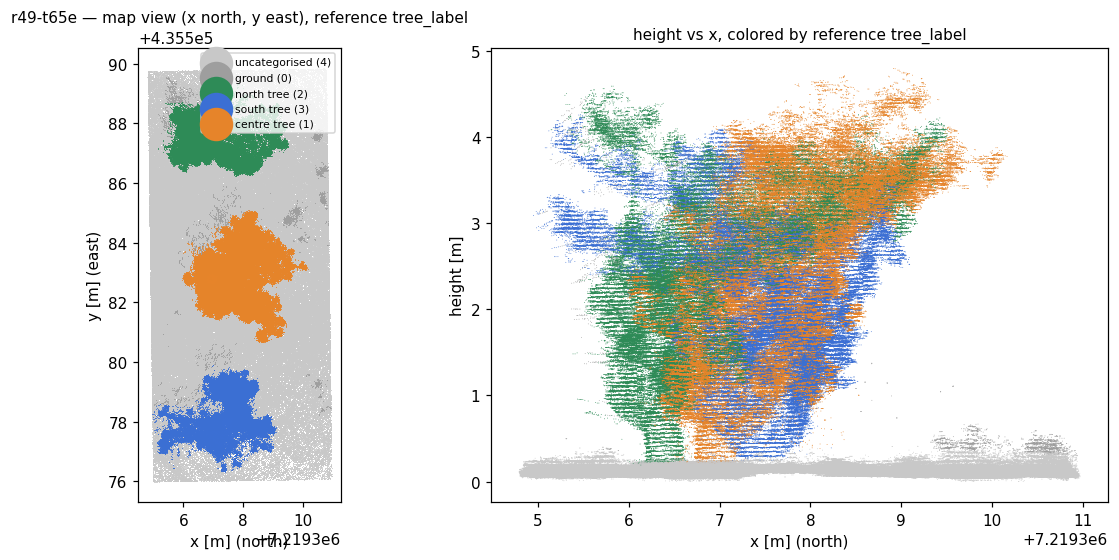

In [ ]:
import numpy as np, matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 110
COL = {0: '#9e9e9e', 1: '#e6842a', 2: '#2e8b57', 3: '#3b6fd4', 4: '#c8c8c8'}
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for lab in (4, 0, 2, 3, 1):  # draw centre tree last
    m = pc['tree'] == lab
    axes[0].scatter(pc['x'][m], pc['y'][m], s=0.3, c=COL[lab], linewidths=0,
                    label={0: 'ground (0)', 1: 'centre tree (1)', 2: 'north tree (2)',
                           3: 'south tree (3)', 4: 'uncategorised (4)'}[lab])
axes[0].set_title('r49-t65e — map view (x north, y east), reference tree_label', fontsize=10)
axes[0].set_xlabel('x [m] (north)'); axes[0].set_ylabel('y [m] (east)')
axes[0].set_aspect('equal'); axes[0].legend(markerscale=40, fontsize=7, loc='upper right')
axes[1].scatter(pc['x'], pc['h'], s=0.3, c=[COL[t] for t in pc['tree']], linewidths=0)
axes[1].set_title('height vs x, colored by reference tree_label', fontsize=10)
axes[1].set_xlabel('x [m] (north)'); axes[1].set_ylabel('height [m]')
plt.tight_layout(); plt.savefig('/content/out_ref_preview.png'); plt.show()

### 10. Filter the trunk list to this scan and run the authors' `graph-op segment`

The trunk CSV covers many trees; only trunks inside the scan's bounding box apply here
(three, matching the three annotated trees). The segmentation (paper §II-D) assigns every
non-ground voxel to the tree whose trunk has the **shortest graph path**: Dijkstra distances
are computed from each trunk node over the voxel graph (nodes = mean point position per
voxel, edges within radius; paper §II-B), with the pinned defaults (voxel 0.1 m, radius 0.15 m)
and the dataset's `height` field driving the >0.4 m ground shortcut. The output is the full
point cloud with the predicted tree id appended per point.

**（説明）** 幹リストをこのスキャンの範囲に絞り（3本）、著者の `graph-op segment` を
既定パラメータで実行します。各ボクセルは「グラフ最短経路長が最小の幹」に割り当てられます。

In [ ]:
import numpy as np, subprocess, time, os
tr_in = ((tr[:,0] >= pc['x'].min()) & (tr[:,0] <= pc['x'].max()) &
         (tr[:,1] >= pc['y'].min()) & (tr[:,1] <= pc['y'].max()) &
         (tr[:,2] >= pc['z'].min()) & (tr[:,2] <= pc['z'].max()))
trs = tr[tr_in]
print('trunks inside bbox:', len(trs), '| tree ids:', np.unique(trs[:,3]).astype(int).tolist())
np.savetxt('/content/data/trunks_filtered.csv', trs[:, :4], fmt='%.6f,%.6f,%.6f,%d')
t0 = time.time()
r = subprocess.run('graph-op segment /content/data/r49-t65e.bin --binary=3d,2ui,d '
    '--fields=x,y,z,matter_label,tree_label,height --trunks=/content/data/trunks_filtered.csv '
    '--voxel-size=0.1 --radius=0.15 --cores=2 -v '
    '> /content/out_segmented.bin 2> /content/out_segmented.log',
    shell=True, capture_output=True, text=True, timeout=7200,
    env=dict(os.environ, PATH=os.environ['GLS_PATH']))
print('graph-op rc:', r.returncode, '| wall time: %.1f min' % ((time.time() - t0) / 60))
assert r.returncode == 0, r.stderr[-3000:]
print(open('/content/out_segmented.log').read()[-1200:])

trunks inside bbox: 3 | tree ids: [12493642, 12493652, 12493662]


graph-op rc: 0 | wall time: 0.2 min
Tempomary directory /tmp/tmp.xtMzpoOOVW
Processing ground
Generating graphs
Generating edge file
Temp dir: /tmp/tmp.0HOUlVk7kg
Not teeing
Starting edge generation
Basic operation
Graph search...
xargs: warning: options --max-lines and --replace/-I/-i are mutually exclusive, ignoring previous --max-lines value
Rejoining PC
CLEANING UP /tmp/tmp.xtMzpoOOVW



### 11. Compare the prediction with the reference labels

Scored points are those the reference marks as one of the three annotated trees
(`tree_label` 1–3) *and* that received a nonzero prediction. v-measure is the paper's
segmentation metric (homogeneity × completeness, invariant to label naming); ARI is a
second, stricter agreement index. The per-tree majority check shows which predicted tree id
each reference tree maps to. A single scan illustrates the method — it is not the paper's
8-tree average.

**（説明）** 予測ラベルと参照ラベル（1〜3 の点のみ）を比較し、v-measure・ARI と
木ごとの対応を計算します。単一スキャンの参考値であり、論文の平均とは別物です。

In [ ]:
import numpy as np, pandas as pd
OUT_DT = np.dtype([('x','<f8'),('y','<f8'),('z','<f8'),('matter','<u4'),('tree','<u4'),('h','<f8'),('pred','<u4')])
seg = np.fromfile('/content/out_segmented.bin', dtype=OUT_DT)
print('output records:', len(seg), '| pred label counts:',
      dict(zip(*np.unique(seg['pred'], return_counts=True))))
mask = (seg['tree'] > 0) & (seg['tree'] < 4) & (seg['pred'] > 0)
assert mask.sum() > 0, 'no scored points — check the graph-op log above'
from sklearn.metrics import v_measure_score, adjusted_rand_score, homogeneity_score, completeness_score
results = pd.DataFrame([{
    'points scored': int(mask.sum()),
    'v_measure': round(v_measure_score(seg['tree'][mask], seg['pred'][mask]), 3),
    'homogeneity': round(homogeneity_score(seg['tree'][mask], seg['pred'][mask]), 3),
    'completeness': round(completeness_score(seg['tree'][mask], seg['pred'][mask]), 3),
    'ARI': round(adjusted_rand_score(seg['tree'][mask], seg['pred'][mask]), 3)}])
print(results.to_string(index=False))
results.to_csv('/content/out_metrics.csv', index=False)

output records: 1308730 | pred label counts: {np.uint32(0): np.int64(685807), np.uint32(12493642): np.int64(171861), np.uint32(12493652): np.int64(294659), np.uint32(12493662): np.int64(156403)}


 points scored  v_measure  homogeneity  completeness  ARI
        622316        1.0          1.0           1.0  1.0


### 12. Result view — reference annotation vs prediction, side by side

Left: the dataset's human labels (same colors as the input preview). Right: the graph-based
prediction from the authors' script (each predicted tree id gets a distinct color; points
without a prediction are light grey). Boundary and canopy errors are where the voxel graph
disconnects — the paper's §IV discusses this error mode.

**（説明）** 左に参照ラベル、右に予測ラベルを並べて表示します。予測は予測ツリーID
ごとの色分け（未割り当ては明灰）。

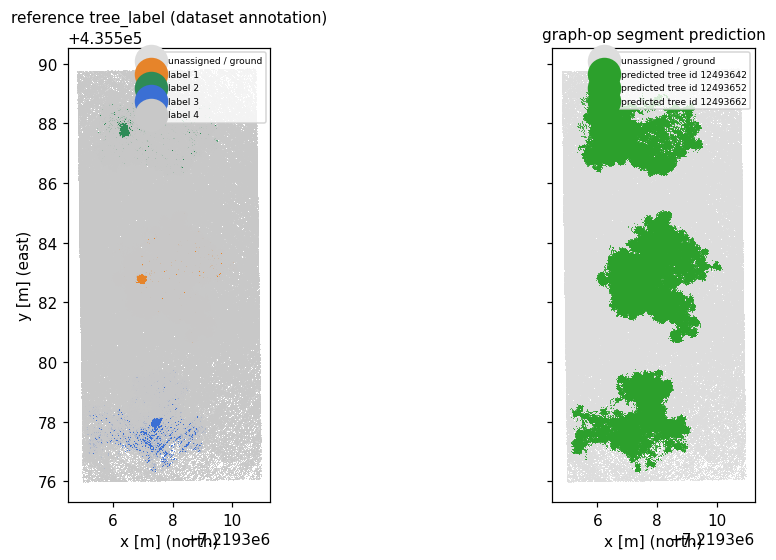

In [ ]:
import numpy as np, matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharex=True, sharey=True)
for ax, vals, ttl in ((axes[0], seg['tree'], 'reference tree_label (dataset annotation)'),
                      (axes[1], seg['pred'], 'graph-op segment prediction')):
    for v in np.unique(vals):
        m = vals == v
        if v == 0:
            c, lab = '#dddddd', 'unassigned / ground'
        elif ttl.startswith('reference'):
            c, lab = COL.get(int(v), '#777777'), f'label {int(v)}'
        else:
            c, lab = plt.cm.tab10(int(v) % 10), f'predicted tree id {int(v)}'
        ax.scatter(seg['x'][m], seg['y'][m], s=0.3, color=c, linewidths=0, label=lab)
    ax.set_title(ttl, fontsize=10); ax.set_xlabel('x [m] (north)')
    ax.set_aspect('equal'); ax.legend(markerscale=40, fontsize=6, loc='upper right')
axes[0].set_ylabel('y [m] (east)')
plt.tight_layout(); plt.savefig('/content/out_prediction.png'); plt.show()

### 13. Per-tree agreement table and CSV export

Per-reference-tree counts against each tree's majority predicted id localise agreement and
errors; the full per-point table is exported as CSV inside Colab.

**（説明）** 参照木ごとの多数決一致率の表と、点ごとの全結果 CSV を Colab 内に書き出します。

In [ ]:
import pandas as pd
scored = seg[(seg['tree'] > 0) & (seg['tree'] < 4) & (seg['pred'] > 0)]
rows = []
for lab in (1, 2, 3):
    m = scored['tree'] == lab
    if m.sum():
        maj = pd.Series(scored['pred'][m]).value_counts().index[0]
        rows.append({'reference tree_label': lab, 'points': int(m.sum()),
                     'majority predicted id': int(maj),
                     'fraction with majority id': round(float((scored['pred'][m] == maj).mean()), 3)})
print(pd.DataFrame(rows).to_string(index=False))
pd.DataFrame({'x': seg['x'], 'y': seg['y'], 'z': seg['z'], 'height_m': seg['h'],
              'reference_tree': seg['tree'], 'matter_label': seg['matter'],
              'predicted_tree': seg['pred']}).to_csv('/content/out_segmentation_points.csv', index=False)
print('saved /content/out_segmentation_points.csv')

 reference tree_label  points  majority predicted id  fraction with majority id
                    1  294391               12493652                        1.0
                    2  171599               12493642                        1.0
                    3  156326               12493662                        1.0


saved /content/out_segmentation_points.csv


## 14. Interpretation, limitations and references

**What this run shows.** The authors' pipeline — voxelise → build a radius graph → graph
search from each trunk → assign by shortest path (paper §II-B/II-D) — runs unmodified from
the pinned revisions on a published scan and produces an individual-tree segmentation
compared above against the dataset's reference annotation. The measured metrics and the
per-tree majority table are in the outputs of sections 11 and 13.

**What it does not show.** Dataset-level results (8-tree averages, trunk-detection F1 0.774,
matter-classification F1 0.482, virtual-scan sweeps, enrichment) are out of scope; one scan
with default parameters does not validate those numbers. The `find-trunks`/`classify`
operations were not run (they need snark applications that link classic TBB, unavailable on
this toolchain — see §1). Matter classification on this scan would additionally need a
decision on the dataset's third `matter_label` value, which the Mendeley description does not
document.

**Provenance.** Paper: CEA 187:106270 / arXiv:2009.13727v2. Code: fwestling/GraphTreeLS
`dc9ca8c7`; helpers `graph-edge`/`points-ground` from fwestling/PruneTreeLS `bf250908`
(phenotyping-lidar/); toolchain fwestling/comma `97fd3d19` + fwestling/snark `a3f26adb`
(C++ identical to archived acfr/comma `8b6ae021` and acfr/snark `6a6ddc79`, BSD-style © 2011
University of Sydney). Data: Mendeley DOI 10.17632/h49fpprg6c.1, CC BY 4.0. The notebook's
setup/parse/eval/plot cells are AI-authored; all scientific operations are the authors' own
code and scripts.

**参考:** 本実行は著者コードをそのまま用いた単一スキャンの部分再現です。データセット
全体の成果の検証ではありません。科学的中核はすべて著者コード、環境構築・評価セルのみ
AI 作成です。